In [ ]:
# Machine Learning
# Aim - To predict the Net Hourly Electrical Energy Output (PE) of a Combined Cycle
# Power Plant using Ambient Temperature (AT), Exhaust Vacuum (V), Ambient Pressure (AP)
# and Relative Humidity (RH)

# importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# loading data set
df = pd.read_csv('power_plant_regression.csv')
df


,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43
...,...,...,...,...,...
9563,15.12,48.92,1011.80,72.93,462.59
9564,33.41,77.95,1010.30,59.72,432.90
9565,15.99,43.34,1014.20,78.66,465.96
9566,17.65,59.87,1018.58,94.65,450.93


In [62]:

# Data Information Gathering
# shape
df.shape


(9568, 5)

In [63]:

# info
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [64]:

# count - Count non-NA cells for each column
df.count()


AT    9568
V     9568
AP    9568
RH    9568
PE    9568
dtype: int64

In [65]:

# head
df.head(2)


,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75


In [66]:

# tail
df.tail(2)


,AT,V,AP,RH,PE
9566,17.65,59.87,1018.58,94.65,450.93
9567,23.68,51.30,1011.86,71.24,451.67


In [67]:

df.min()


AT      1.81
V      25.36
AP    992.89
RH     25.56
PE    420.26
dtype: float64

In [68]:

df.max()


AT      37.11
V       81.56
AP    1033.30
RH     100.16
PE     495.76
dtype: float64

In [69]:

df.describe()
# 25% - First quartile (Q1)
# 50% - Second quartile - median (Q2)
# 75% - Third quartile (Q3)


,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


In [70]:

# Data Cleaning
# null values
df.isnull().sum()


AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [71]:

# duplicates
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df = df.reset_index(drop=True)
df


,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43
...,...,...,...,...,...
9522,15.12,48.92,1011.80,72.93,462.59
9523,33.41,77.95,1010.30,59.72,432.90
9524,15.99,43.34,1014.20,78.66,465.96
9525,17.65,59.87,1018.58,94.65,450.93


<Axes: >

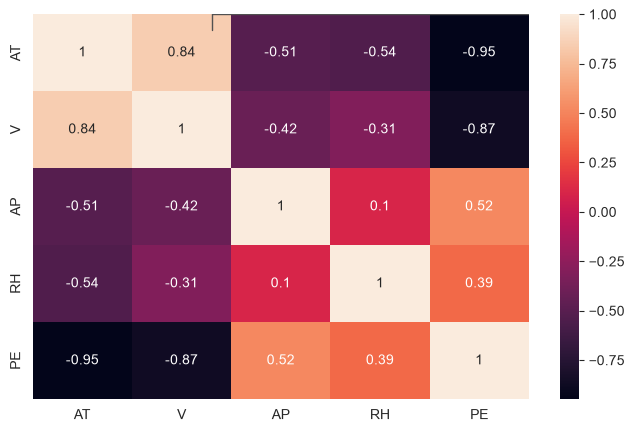

In [72]:

# Data Visualization
import seaborn as sns
sns.scatterplot(x='AT', y='PE', data=df)
sns.boxplot(x='AT', data=df)
sns.regplot(x='AT', y='PE', data=df)
sns.heatmap(df.corr(), annot=True)


In [73]:

# Split X and Y
X = df[['AT', 'V', 'AP', 'RH']]
Y = df['PE']


In [74]:

# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=42)


In [75]:

X_train


,AT,V,AP,RH
5695,18.52,58.41,1013.77,99.89
7300,8.51,39.66,1015.16,86.61
9066,13.07,42.18,1014.98,87.77
6424,30.07,69.82,1010.39,57.53
6773,13.52,42.34,1017.97,95.34
...,...,...,...,...
5734,18.84,40.79,1005.18,92.46
5191,30.66,73.77,1003.13,78.09
5390,19.79,51.19,1008.77,94.72
860,26.73,68.84,1010.75,66.83


In [76]:

X_test


,AT,V,AP,RH
1087,33.26,68.51,1012.49,52.68
6308,8.48,38.50,1013.50,66.51
8021,8.75,36.30,1015.61,57.53
9483,20.78,62.52,1017.58,73.30
4459,19.39,68.61,1011.09,96.51
...,...,...,...,...
3400,3.74,35.19,1018.58,98.84
4210,21.45,69.94,1010.50,82.17
7065,26.82,75.08,1005.93,60.81
2213,30.33,70.36,1006.72,70.31


In [77]:

y_train


5695    446.68
7300    483.54
9066    461.71
6424    437.38
6773    463.71
         ...  
5734    459.96
5191    430.00
5390    447.96
860     440.45
7270    451.14
Name: PE, Length: 7621, dtype: float64

In [78]:

y_test


1087    429.38
6308    485.29
8021    480.40
9483    452.30
4459    446.47
         ...  
3400    490.50
4210    443.31
7065    441.14
2213    438.47
4983    436.85
Name: PE, Length: 1906, dtype: float64

In [79]:
# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_test

array([[ 1.83181156,  1.11850689, -0.13129023, -1.41937939],
       [-1.50828477, -1.24311396,  0.03906858, -0.47087856],
       [-1.47189147, -1.41624178,  0.3949667 , -1.08675256],
       ...,
       [ 0.96376393,  1.63552951, -1.23777918, -0.86180081],
       [ 1.43687685,  1.26409165, -1.10452823, -0.21026372],
       [ 1.27108514,  1.50332282, -0.32357642, -1.10184079]],
      shape=(1906, 4))

In [80]:

# Building, Training and Testing Model
# Algorithm 1 - Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

regression_LR = LinearRegression()

regression_LR.fit(X_train, y_train)

y_pred = regression_LR.predict(X_test)

S_LR = r2_score(y_test, y_pred)
print(S_LR)

# Predicting the Model
# sample input -> [AT, V, AP, RH]
P_LR = regression_LR.predict(scaler.transform([[15.0, 40.0, 1010.0, 75.0]]))
P_LR

import pandas as pd
a = pd.DataFrame({'Algorithm': ['Linear Regression'],
                  'R2Score': [S_LR],
                  'Actual1': [463],
                  'Prediction1': [P_LR]})
a


0.930770359025058


c:\Users\Student\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,Algorithm,R2Score,Actual1,Prediction1
0,Linear Regression,0.93077,463,[466.43273729084933]


In [81]:

# Algorithm 2 - Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

# Create the model
regression_DT = DecisionTreeRegressor(random_state=42)

# Train the model
regression_DT.fit(X_train, y_train)

# Make predictions
y_pred = regression_DT.predict(X_test)

# Calculate R² score
S_DT = r2_score(y_test, y_pred)

# Print the score
print("R² Score:", S_DT)

P_DT = regression_DT.predict(scaler.transform([[15.0, 40.0, 1010.0, 75.0]]))
P_DT

import pandas as pd
a = pd.DataFrame({'Algorithm': ['Linear Regression', 'Decision Tree Regressor'],
                  'R2Score': [S_LR, S_DT],
                  'Actual1': [463, 463],
                  'Prediction1': [P_LR, P_DT]})
a


R² Score: 0.9329937687899192


c:\Users\Student\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,Algorithm,R2Score,Actual1,Prediction1
0,Linear Regression,0.930770,463,[466.43273729084933]
1,Decision Tree Regressor,0.932994,463,[458.46]


In [82]:

# Algorithm 3 - Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Create the model
regression_RF = RandomForestRegressor(random_state=42)

# Train the model
regression_RF.fit(X_train, y_train)

# Make predictions
y_pred = regression_RF.predict(X_test)

# Calculate R² score
S_RF = r2_score(y_test, y_pred)

# Print the score
print("R² Score:", S_RF)

P_RF = regression_RF.predict(scaler.transform([[15.0, 40.0, 1010.0, 75.0]]))
P_RF

import pandas as pd
a = pd.DataFrame({'Algorithm': ['Linear Regression', 'Decision Tree Regressor', 'Random Forest Regressor'],
                  'R2Score': [S_LR, S_DT, S_RF],
                  'Actual1': [463, 463, 463],
                  'Prediction1': [P_LR, P_DT, P_RF]})
a


R² Score: 0.9650617721826878


c:\Users\Student\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,Algorithm,R2Score,Actual1,Prediction1
0,Linear Regression,0.930770,463,[466.43273729084933]
1,Decision Tree Regressor,0.932994,463,[458.46]
2,Random Forest Regressor,0.965062,463,[465.8122999999999]


In [83]:

# Algorithm 4 - Support Vector Regressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score

# Create the model
regression_SVR = SVR()

# Train the model
regression_SVR.fit(X_train, y_train)

# Make predictions
y_pred = regression_SVR.predict(X_test)

# Calculate R² score
S_SVR = r2_score(y_test, y_pred)

# Print the score
print("R² Score:", S_SVR)

P_SVR = regression_SVR.predict(scaler.transform([[15.0, 40.0, 1010.0, 75.0]]))
P_SVR

import pandas as pd
a = pd.DataFrame({'Algorithm': ['Linear Regression', 'Decision Tree Regressor', 'Random Forest Regressor', 'Support Vector Machine Regressor'],
                  'R2Score': [S_LR, S_DT, S_RF, S_SVR],
                  'Actual1': [463, 463, 463, 463],
                  'Prediction1': [P_LR, P_DT, P_RF, P_SVR]})
a


R² Score: 0.9424867977162007


c:\Users\Student\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,Algorithm,R2Score,Actual1,Prediction1
0,Linear Regression,0.930770,463,[466.43273729084933]
1,Decision Tree Regressor,0.932994,463,[458.46]
2,Random Forest Regressor,0.965062,463,[465.8122999999999]
3,Support Vector Machine Regressor,0.942487,463,[467.21870961040236]


In [84]:

# Algorithm 5 - KNN Regressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

# Create the model
regression_KNN = KNeighborsRegressor()

# Train the model
regression_KNN.fit(X_train, y_train)

# Make predictions
y_pred = regression_KNN.predict(X_test)

# Calculate R² score
S_KNN = r2_score(y_test, y_pred)

# Print the score
print("R² Score:", S_KNN)

P_KNN = regression_KNN.predict(scaler.transform([[15.0, 40.0, 1010.0, 75.0]]))
P_KNN

import pandas as pd
a = pd.DataFrame({'Algorithm': ['Linear Regression', 'Decision Tree Regressor', 'Random Forest Regressor', 'Support Vector Machine Regressor', 'KNN'],
                  'R2Score': [S_LR, S_DT, S_RF, S_SVR, S_KNN],
                  'Actual1': [463, 463, 463, 463, 463],
                  'Prediction1': [P_LR, P_DT, P_RF, P_SVR, P_KNN]})
a


R² Score: 0.9521233871159646


c:\Users\Student\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,Algorithm,R2Score,Actual1,Prediction1
0,Linear Regression,0.930770,463,[466.43273729084933]
1,Decision Tree Regressor,0.932994,463,[458.46]
2,Random Forest Regressor,0.965062,463,[465.8122999999999]
3,Support Vector Machine Regressor,0.942487,463,[467.21870961040236]
4,KNN,0.952123,463,[466.50200000000007]


In [85]:

# Algorithm 6 - Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

# Create the model
regression_GB = GradientBoostingRegressor(random_state=42)

# Train the model
regression_GB.fit(X_train, y_train)

# Make predictions
y_pred = regression_GB.predict(X_test)

# Calculate R² score
S_GB = r2_score(y_test, y_pred)

# Print the score
print("R² Score:", S_GB)

P_GB = regression_GB.predict(scaler.transform([[15.0, 40.0, 1010.0, 75.0]]))
P_GB

import pandas as pd
a = pd.DataFrame({'Algorithm': ['Linear Regression', 'Decision Tree Regressor', 'Random Forest Regressor', 'Support Vector Machine Regressor', 'KNN', 'Gradient Boosting Regressor'],
                  'R2Score': [S_LR, S_DT, S_RF, S_SVR, S_KNN, S_GB],
                  'Actual1': [463, 463, 463, 463, 463, 463],
                  'Prediction1': [P_LR, P_DT, P_RF, P_SVR, P_KNN, P_GB]})
a

R² Score: 0.9522574594606155


c:\Users\Student\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,Algorithm,R2Score,Actual1,Prediction1
0,Linear Regression,0.930770,463,[466.43273729084933]
1,Decision Tree Regressor,0.932994,463,[458.46]
2,Random Forest Regressor,0.965062,463,[465.8122999999999]
3,Support Vector Machine Regressor,0.942487,463,[467.21870961040236]
4,KNN,0.952123,463,[466.50200000000007]
5,Gradient Boosting Regressor,0.952257,463,[465.53108902375925]


In [86]:
# Prediction Comparison with R2 Score


comparison = pd.DataFrame({

    'Actual PE': [
        'R2 Score',
        actual_values[0],
        actual_values[1],
        actual_values[2]
    ],


    'Linear Regression ': [
        S_LR,
        LR_prediction[0],
        LR_prediction[1],
        LR_prediction[2]
    ],


    'Decision Tree Regressor': [
        S_DT,
        DT_prediction[0],
        DT_prediction[1],
        DT_prediction[2]
    ],


    'Random Forest Regressor': [
        S_RF,
        RF_prediction[0],
        RF_prediction[1],
        RF_prediction[2]
    ],


    'SVR': [
        S_SVR,
        SVR_prediction[0],
        SVR_prediction[1],
        SVR_prediction[2]
    ],


    'KNN': [
        S_KNN,
        KNN_prediction[0],
        KNN_prediction[1],
        KNN_prediction[2]
    ],


    'Gradient Boosting Regressor': [
        S_GB,
        GB_prediction[0],
        GB_prediction[1],
        GB_prediction[2]
    ]

})


comparison.index = [
    'R2 Score',
    'Sample 1',
    'Sample 2',
    'Sample 3'
]


comparison

,Actual PE,Linear Regression,Decision Tree Regressor,Random Forest Regressor,SVR,KNN,Gradient Boosting Regressor
R2 Score,R2 Score,0.930770,0.932994,0.965062,0.942487,0.952123,0.952257
Sample 1,429.38,427.458958,428.890000,430.828600,434.172630,430.096000,433.835201
Sample 2,485.29,481.110411,485.310000,483.481700,480.435598,481.796000,482.075109
Sample 3,480.4,482.638164,477.380000,463.717800,477.698793,471.492000,478.472356
